# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


Epoch [1/20], Loss: 0.6881, 학습 정확도: 68.50%, 평가 정확도: 69.90%
Epoch [2/20], Loss: 0.6517, 학습 정확도: 70.28%, 평가 정확도: 70.29%
Epoch [3/20], Loss: 0.6416, 학습 정확도: 70.70%, 평가 정확도: 70.51%
Epoch [4/20], Loss: 0.6355, 학습 정확도: 70.95%, 평가 정확도: 69.99%
Epoch [5/20], Loss: 0.6309, 학습 정확도: 71.13%, 평가 정확도: 70.95%
Epoch [6/20], Loss: 0.6266, 학습 정확도: 71.44%, 평가 정확도: 70.44%
Epoch [7/20], Loss: 0.6234, 학습 정확도: 71.49%, 평가 정확도: 70.87%
Epoch [8/20], Loss: 0.6203, 학습 정확도: 71.62%, 평가 정확도: 70.70%
Epoch [9/20], Loss: 0.6167, 학습 정확도: 71.63%, 평가 정확도: 70.72%
Epoch [10/20], Loss: 0.6152, 학습 정확도: 71.78%, 평가 정확도: 70.85%
Epoch [11/20], Loss: 0.6119, 학습 정확도: 72.04%, 평가 정확도: 71.11%
Epoch [12/20], Loss: 0.6093, 학습 정확도: 72.17%, 평가 정확도: 71.11%
Epoch [13/20], Loss: 0.6071, 학습 정확도: 72.26%, 평가 정확도: 71.39%
Epoch [14/20], Loss: 0.6052, 학습 정확도: 72.36%, 평가 정확도: 70.98%
Epoch [15/20], Loss: 0.6030, 학습 정확도: 72.38%, 평가 정확도: 71.48%
Epoch [16/20], Loss: 0.6002, 학습 정확도: 72.59%, 평가 정확도: 71.44%
Epoch [17/20], Loss: 0.5980, 학습 정확도: 72.66%, 평가 정

# 환경 설정

In [42]:
# 코랩 한글 폰트 설정
import matplotlib as mpl
import matplotlib.pyplot as plt

!apt-get install -y fonts-nanum
!fc-cache -fv

mpl.font_manager._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype

In [43]:
# 필요 라이브러리 불러오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn

# 데이터 탐색 및 전처리

In [44]:
# 데이터 탐색 및 전처리 플로우
# 1. 데이터 불러오기
# 2. "train2.csv" 데이터는 설명서의 "Month : 해당 연도의 월"을 참고하여, 특정 1년 사이의 월별 집계 데이터로 판단.
# 3. 시계열 사용여부를 판단
# 4. 최소한의 컬럼을 제거하고, 범주형 데이터의 라벨링을 진행함 (결과는 아래 서술)

df = pd.read_csv('train2.csv')
print(f"원본 shape: {df.shape}")
print(f"고객 수: {df['Customer_ID'].nunique()}, 월 범위: {sorted(df['Month'].unique())}\n")
df.info()

원본 shape: (100000, 28)
고객 수: 12500, 월 범위: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_

In [45]:
# object 컬럼 탐색 — 인코딩 방식 결정 전 값 확인
object_cols = df.select_dtypes(include='object').columns.tolist()
print("=" * 55)
print(f"object 컬럼 탐색: {object_cols}")
print("=" * 55)

for col in object_cols:
    print(f"\n▶ {col}")
    print(f"  유니크값 수: {df[col].nunique()}")
    print(f"  분포:\n{df[col].value_counts().head(5)}")

object 컬럼 탐색: ['Name', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']

▶ Name
  유니크값 수: 10128
  분포:
Name
Stevex      48
Langep      48
Jessicad    48
Nicko       40
Johnc       40
Name: count, dtype: int64

▶ Occupation
  유니크값 수: 15
  분포:
Occupation
Lawyer        7096
Engineer      6864
Architect     6824
Mechanic      6776
Accountant    6744
Name: count, dtype: int64

▶ Type_of_Loan
  유니크값 수: 6261
  분포:
Type_of_Loan
No Data                    11408
not specified               1408
credit-builder loan         1280
personal loan               1272
debt consolidation loan     1264
Name: count, dtype: int64

▶ Credit_Mix
  유니크값 수: 3
  분포:
Credit_Mix
Standard    45848
Good        30384
Bad         23768
Name: count, dtype: int64

▶ Payment_of_Min_Amount
  유니크값 수: 3
  분포:
Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64

▶ Payment_Behaviour
  유니크값 수: 6
  분포:
Payment_Behaviour
Low_spent_Small_val

In [46]:
print(df.select_dtypes(include='object').nunique().to_string())
# Type_of_Loan의 데이터 형태 확인 필요
# 나머지는 클래스의 속성에 따른 라벨인코딩 실행

Name                     10128
Occupation                  15
Type_of_Loan              6261
Credit_Mix                   3
Payment_of_Min_Amount        3
Payment_Behaviour            6
Credit_Score                 3


In [47]:
# Type_of_Loan 컬럼 분석 — 멀티레이블 여부 확인
print("=== Type_of_Loan 샘플 5개 ===")
print(df['Type_of_Loan'].head())

print(f"\n=== 쉼표 포함 비율 ===")
has_comma = df['Type_of_Loan'].str.contains(',', na=False)
print(f"쉼표 포함 행: {has_comma.sum():,}개 ({has_comma.mean()*100:.1f}%)")
print(f"쉼표 없는 행: {(~has_comma).sum():,}개 ({(~has_comma).mean()*100:.1f}%)")

print(f"\n=== 행당 대출 종류 수 분포 ===")
loan_count_per_row = df['Type_of_Loan'].apply(
    lambda x: len(x.split(',')) if pd.notna(x) else 0
)
print(loan_count_per_row.value_counts().sort_index())

print(f"\n=== 유니크 조합 수 vs 단일 종류 수 ===")
print(f"value_counts() 유니크 수 (조합): {df['Type_of_Loan'].nunique():,}개")

unique_loans = set()
for val in df['Type_of_Loan'].dropna():
    for t in val.split(','):
        unique_loans.add(t.strip().lower())
print(f"실제 단일 대출 종류 수: {len(unique_loans)}개")
print(f"종류 목록: {sorted(unique_loans)}")

=== Type_of_Loan 샘플 5개 ===
0    auto loan,credit-builder loan,personal loan,ho...
1    auto loan,credit-builder loan,personal loan,ho...
2    auto loan,credit-builder loan,personal loan,ho...
3    auto loan,credit-builder loan,personal loan,ho...
4    auto loan,credit-builder loan,personal loan,ho...
Name: Type_of_Loan, dtype: object

=== 쉼표 포함 비율 ===
쉼표 포함 행: 77,464개 (77.5%)
쉼표 없는 행: 22,536개 (22.5%)

=== 행당 대출 종류 수 분포 ===
Type_of_Loan
1    22536
2    15712
3    15752
4    15456
5     7528
6     8144
7     7680
8     3336
9     3856
Name: count, dtype: int64

=== 유니크 조합 수 vs 단일 종류 수 ===
value_counts() 유니크 수 (조합): 6,261개
실제 단일 대출 종류 수: 10개
종류 목록: ['auto loan', 'credit-builder loan', 'debt consolidation loan', 'home equity loan', 'mortgage loan', 'no data', 'not specified', 'payday loan', 'personal loan', 'student loan']


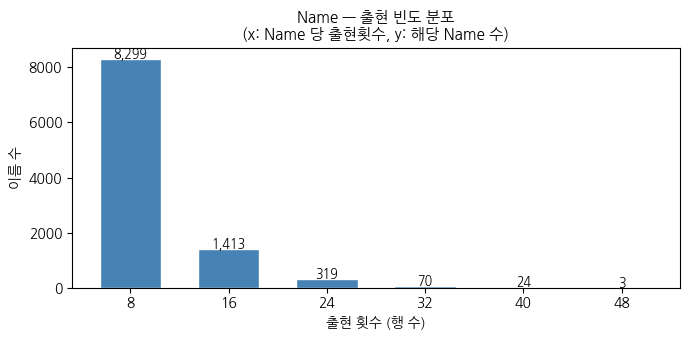

  유니크 이름 수: 10,128  |  최소 출현: 8회  |  최대 출현: 48회


In [48]:
# 범주형 컬럼 시각화
# Name — 출현 빈도 분포 (동명이인 고려, Customer_ID 기준 패널 구조 확인용)
name_counts = df['Name'].value_counts()
freq_dist   = name_counts.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(freq_dist.index, freq_dist.values, width=5, color='steelblue', edgecolor='white')
ax.set_title('Name — 출현 빈도 분포\n(x: Name 당 출현횟수, y: 해당 Name 수)', fontsize=11)
ax.set_xlabel('출현 횟수 (행 수)')
ax.set_ylabel('이름 수')
for x, y in zip(freq_dist.index, freq_dist.values):
    ax.text(x, y + 30, f'{y:,}', ha='center', fontsize=9)
ax.set_xticks(freq_dist.index)
plt.tight_layout()
plt.show()
print(f"  유니크 이름 수: {len(name_counts):,}  |  최소 출현: {freq_dist.index.min()}회  |  최대 출현: {freq_dist.index.max()}회")

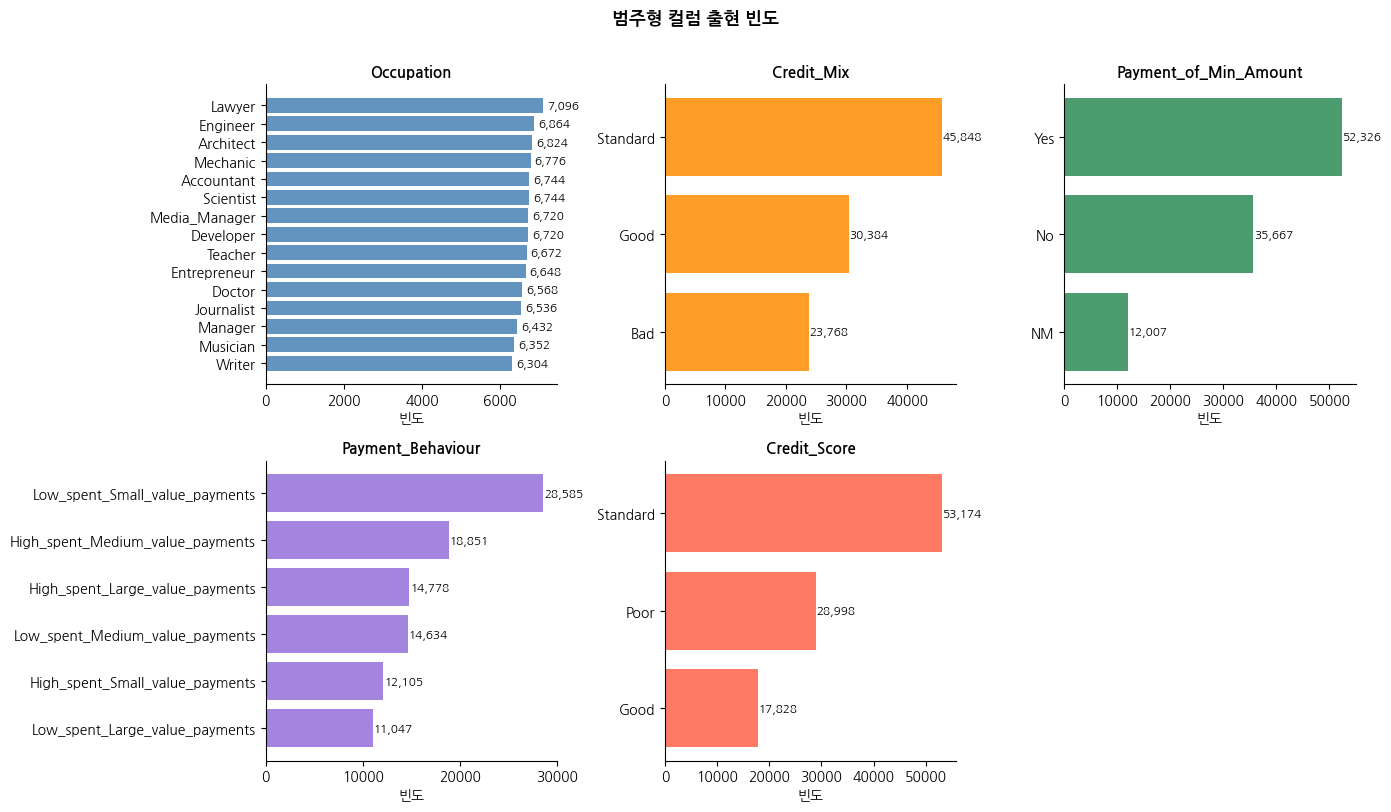

In [49]:
# 나머지 범주형 컬럼 출현 빈도
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'tomato']

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    ax = axes[i]
    bars = ax.barh(vc.index[::-1], vc.values[::-1], color=colors[i], alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('빈도')
    for bar, val in zip(bars, vc.values[::-1]):
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_visible(False)
plt.suptitle('범주형 컬럼 출현 빈도', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [50]:
# 패널 구조 확인
# Customer_ID 기준 출현 횟수
customer_counts = df.groupby('Customer_ID')['Month'].count()
print(f"Customer_ID별 출현 횟수")
print(f"최대: {customer_counts.max()}회")
print(f"최소: {customer_counts.min()}회")
print(f"평균: {customer_counts.mean():.1f}회")
print(f"\n분포:\n{customer_counts.value_counts().sort_index()}")

Customer_ID별 출현 횟수
최대: 8회
최소: 8회
평균: 8.0회

분포:
Month
8    12500
Name: count, dtype: int64


In [51]:
# 모든 고객이 1~8월에 존재하는지 확인
customer_months = df.groupby('Customer_ID')['Month'].apply(set)
expected = set(range(1, 9))
incomplete = customer_months[customer_months != expected]

print(f"전체 고객 수: {df['Customer_ID'].nunique():,}")
print(f"1~8월 모두 보유한 고객: {(customer_months == expected).sum():,}")
print(f"누락된 월이 있는 고객: {len(incomplete):,}")

전체 고객 수: 12,500
1~8월 모두 보유한 고객: 12,500
누락된 월이 있는 고객: 0


In [52]:
# 고객별 Age 변화 확인 — 시계열 사용 가능 여부 판단
age_diff = df.groupby('Customer_ID')['Age'].agg(lambda x: x.max() - x.min())
print(f"Age 변화 없는 고객 (diff=0): {(age_diff == 0).sum():,}")
print(f"Age 1 차이 고객 (diff=1): {(age_diff == 1).sum():,}")
print(f"Age 2 이상 차이 고객 (diff>=2): {(age_diff >= 2).sum():,}")
print(f"\n최대 Age 변화폭: {age_diff.max()}")

Age 변화 없는 고객 (diff=0): 5,302
Age 1 차이 고객 (diff=1): 7,198
Age 2 이상 차이 고객 (diff>=2): 0

최대 Age 변화폭: 1


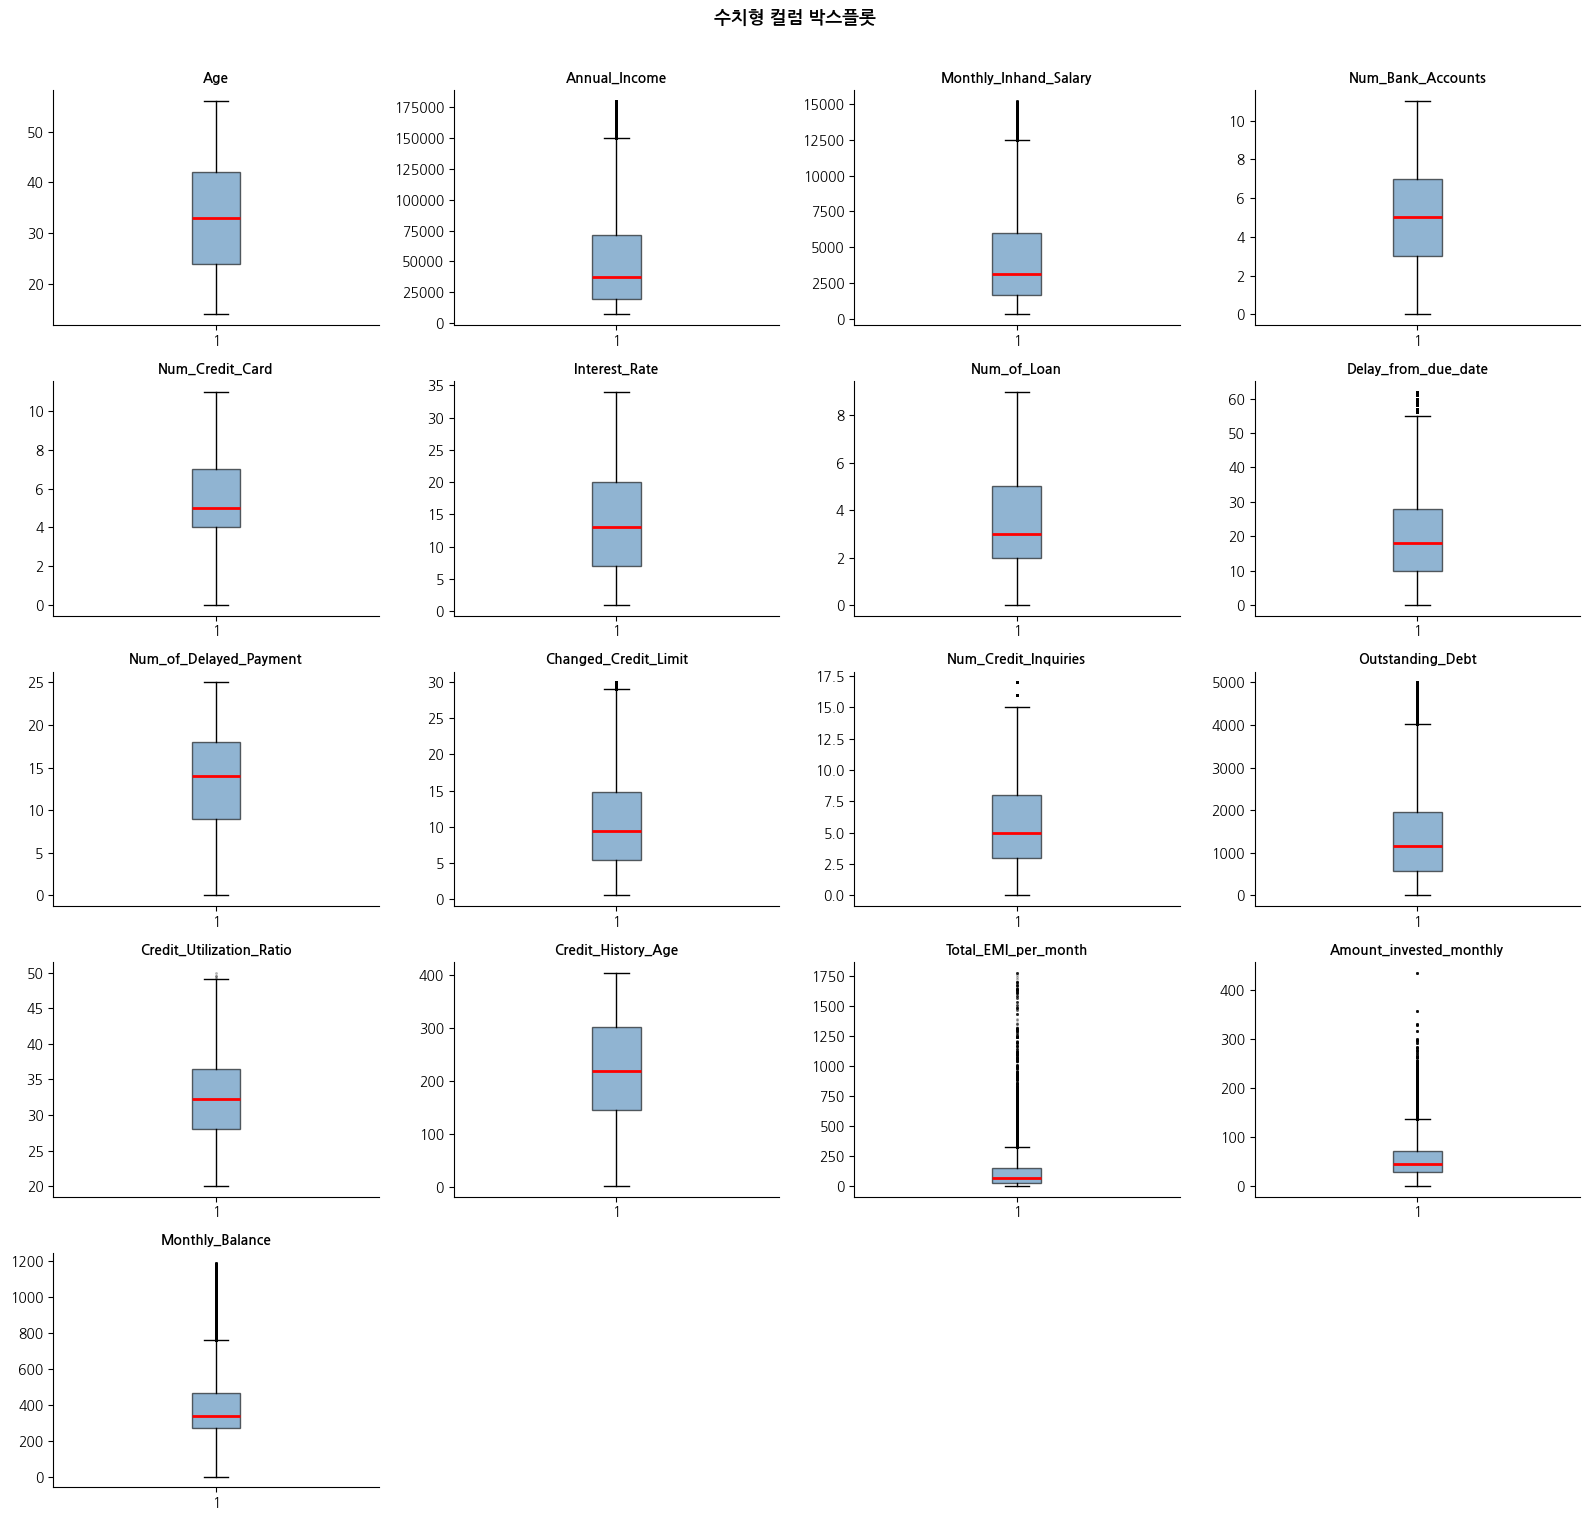

In [53]:
# 수치형 컬럼 시각화
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['ID', 'Customer_ID', 'Month', 'SSN']]

n = len(num_cols)
ncols = 4
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].spines[['top', 'right']].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 컬럼 박스플롯', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

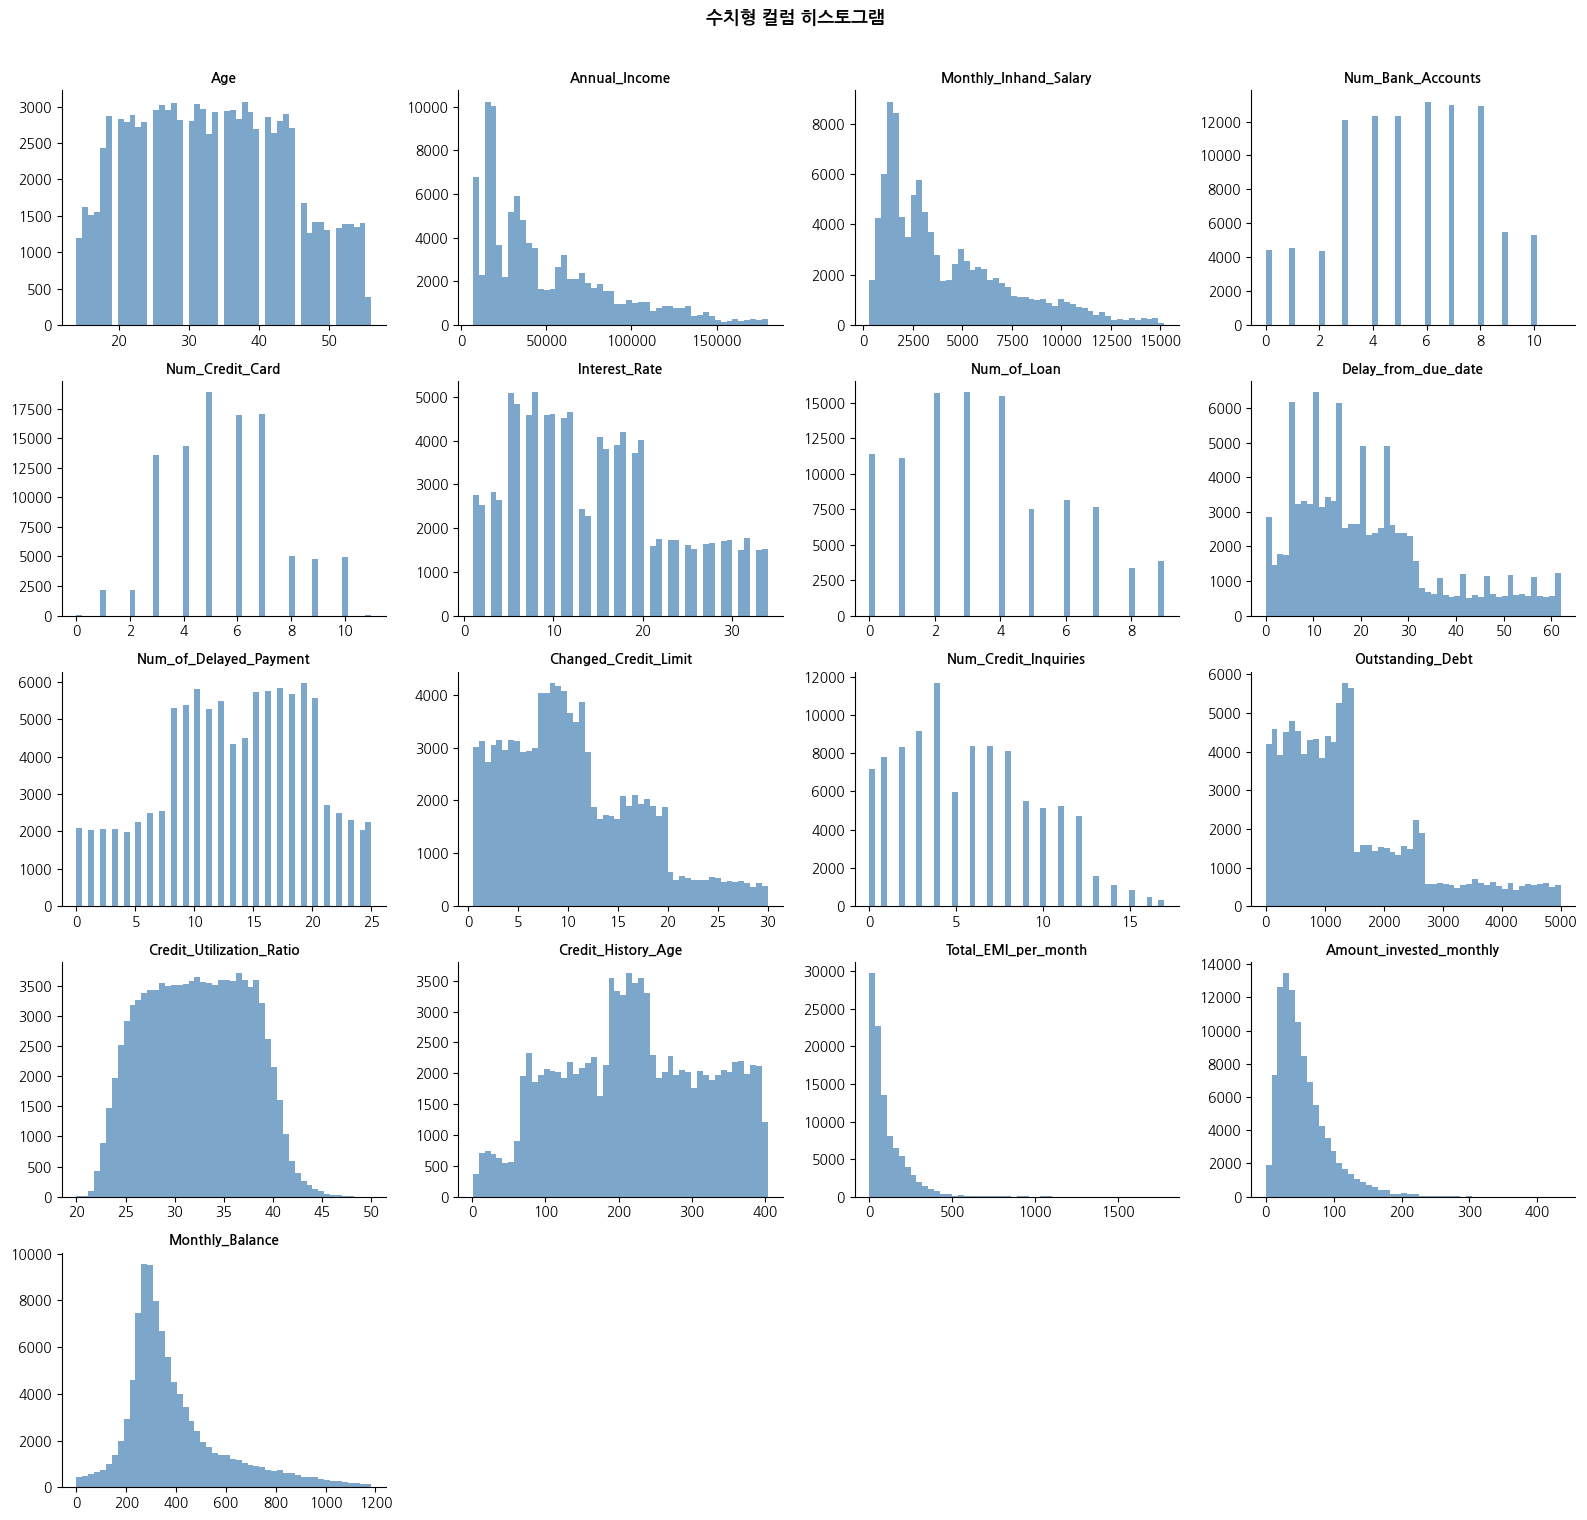

In [54]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].spines[['top', 'right']].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 컬럼 히스토그램', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [55]:
# 전체 데이터 탐색
# 총 고객 수(중복 제외 Customer_ID)는 12500이며, Month는 1~8의 정수로 존재함
# 모든 고객의 대한 정보는 특정년도의 1~8월 데이터임을 증명

# 범주형 데이터 탐색 결과
# 1. Type_of_Loan은 쉼표로 구분된 멀티레이블로, 더미변수화 진행
# 2. 각 Customer_ID가 모든 Month에 분포는 모두 존재하여 시간의 흐름에 고려 가능
# 3. 한 고객의 시점은 8개로 시계열을 사용하지 않는 것을 전제하기로 함
# 4. Payment_Behaviour는 spent_level, payment_size의 두 가지 특징을 반영함

# 숫자형 데이터 탐색 결과
# 1. 시각화 결과, 연속 분포와 이산 분포의 특징을 확인
# 2. 데이터의 무결성을 위해 별도의 전처리보다는 모델 선정 및 리스케일링이 중요하다고 판단

# 전처리
# 제거 — ID, Name, SSN (식별자), Customer_ID (모델링 직전 제거), Month 유지
# 추가 — Type_of_Loan 더미변수 분해, Payment_Behaviour 분리
# 범주형 처리 — 순서형/명목형 구별하여 인코딩

In [56]:
# 식별자 컬럼 제거 (Name, ID, SSN)
df.drop(columns=['Name', 'ID', 'SSN'], inplace=True)
print(f"제거 후 shape: {df.shape}")

제거 후 shape: (100000, 25)


In [57]:
# Type_of_Loan 파싱 — 멀티레이블을 종류별 더미변수로 분해
LOAN_TYPES = [
    'auto loan', 'credit-builder loan', 'debt consolidation loan',
    'home equity loan', 'mortgage loan', 'payday loan',
    'personal loan', 'student loan'
]

def parse_loan(text):
    skip = {'no data', 'not specified'}
    if pd.isna(text):
        return []
    return [t.strip().lower() for t in text.split(',')
            if t.strip().lower() not in skip]

for loan in LOAN_TYPES:
    col_name = 'loan_' + loan.replace(' ', '_').replace('-', '_')
    df[col_name] = df['Type_of_Loan'].apply(lambda x: 1 if loan in parse_loan(x) else 0)

df.drop(columns=['Type_of_Loan'], inplace=True)
print(f"생성된 loan 컬럼: {[c for c in df.columns if c.startswith('loan_')]}")

생성된 loan 컬럼: ['loan_auto_loan', 'loan_credit_builder_loan', 'loan_debt_consolidation_loan', 'loan_home_equity_loan', 'loan_mortgage_loan', 'loan_payday_loan', 'loan_personal_loan', 'loan_student_loan']


In [58]:
# Payment_Behaviour 분리
# "High_spent_Large_value_payments" → spent_level (High=1, Low=0) / payment_size (Small=0, Medium=1, Large=2)
spent_map = {'Low': 0, 'High': 1}
size_map  = {'Small': 0, 'Medium': 1, 'Large': 2}

def parse_behaviour(text):
    try:
        parts = text.split('_spent_')
        return spent_map.get(parts[0], np.nan), size_map.get(parts[1].replace('_value_payments', ''), np.nan)
    except:
        return np.nan, np.nan

df[['spent_level', 'payment_size']] = df['Payment_Behaviour'].apply(
    lambda x: pd.Series(parse_behaviour(x))
)
df.drop(columns=['Payment_Behaviour'], inplace=True)
print("spent_level:", df['spent_level'].value_counts().to_dict())
print("payment_size:", df['payment_size'].value_counts().to_dict())

spent_level: {0: 54266, 1: 45734}
payment_size: {0: 40690, 1: 33485, 2: 25825}


In [59]:
# 범주형 인코딩
# Credit_Mix: 순서 있는 범주형 (Bad < Standard < Good)
df['Credit_Mix'] = df['Credit_Mix'].map({'Bad': 0, 'Standard': 1, 'Good': 2})

# Payment_of_Min_Amount: NM(미기재) 별도 카테고리 유지
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1, 'NM': 2})

# Occupation: 순서 없는 명목형 15종 → Label Encoding
le = LabelEncoder()
df['Occupation'] = le.fit_transform(df['Occupation'])
print(f"Occupation 인코딩: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Credit_Score (타겟): Poor=0, Standard=1, Good=2
df['Credit_Score'] = df['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})

print(f"\n최종 shape: {df.shape}")
print(f"결측치:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Occupation 인코딩: {'Accountant': np.int64(0), 'Architect': np.int64(1), 'Developer': np.int64(2), 'Doctor': np.int64(3), 'Engineer': np.int64(4), 'Entrepreneur': np.int64(5), 'Journalist': np.int64(6), 'Lawyer': np.int64(7), 'Manager': np.int64(8), 'Mechanic': np.int64(9), 'Media_Manager': np.int64(10), 'Musician': np.int64(11), 'Scientist': np.int64(12), 'Teacher': np.int64(13), 'Writer': np.int64(14)}

최종 shape: (100000, 33)
결측치:
Series([], dtype: int64)


In [60]:
# 전처리 완료 데이터 저장
df.to_csv('train_preprocessed.csv', index=False)
print("✅ train_preprocessed.csv 저장 완료")

✅ train_preprocessed.csv 저장 완료


# 5. EDA

In [61]:
# EDA 과정 및 결과 요약
# 범주형은 출현 빈도 막대그래프, 수치형은 박스플롯·히스토그램으로 분포를 확인하였다.
# 이후 클래스별 수치형 박스플롯, 범주형 교차분석, 상관관계 히트맵,
# 직업 및 대출 종류별 신용점수 분포를 시각화하였다.
#
# 수치형 피처 중 Interest_Rate(-0.49), Num_Credit_Inquiries(-0.44),
# Delay_from_due_date(-0.43), Outstanding_Debt(-0.39)는 강한 음의 상관을 보였으며,
# Credit_History_Age(0.39), Annual_Income(0.21)는 양의 상관을 보였다.
# Total_EMI_per_month(0.02), Credit_Utilization_Ratio(0.05)는 타겟과 상관이 거의 없었다.
#
# Credit_Mix의 변별력이 가장 강하여 Bad 등급의 Poor 비율이 60%에 달한 반면
# Good 등급은 16%에 불과하였다. Payment_of_Min_Amount에서 최소금액만 납부한
# 고객의 Poor 비율이 40%로 신용 위험 신호로 확인되었다.
# 직업별 분포는 14~19% 수준으로 차이가 미미하여 예측력이 낮은 변수로 판단된다.

data = pd.read_csv('train_preprocessed.csv')

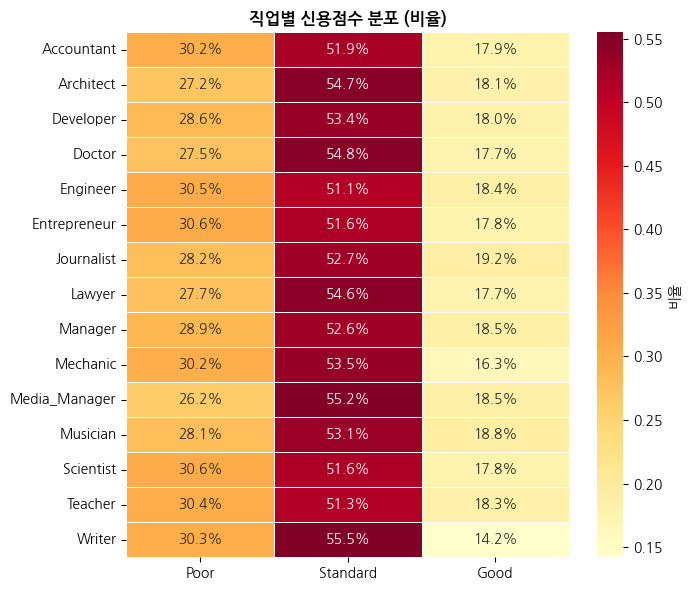

In [62]:
# 직업 라벨 매핑
occ_map = {0:'Accountant', 1:'Architect', 2:'Developer', 3:'Doctor', 4:'Engineer',
           5:'Entrepreneur', 6:'Journalist', 7:'Lawyer', 8:'Manager', 9:'Mechanic',
           10:'Media_Manager', 11:'Musician', 12:'Scientist', 13:'Teacher', 14:'Writer'}
score_map = {0:'Poor', 1:'Standard', 2:'Good'}

# 직업별 신용점수 히트맵
occ_score = data.groupby(['Occupation', 'Credit_Score']).size().unstack(fill_value=0)
occ_score.index = [occ_map[i] for i in occ_score.index]
occ_score.columns = [score_map[c] for c in occ_score.columns]
occ_score_pct = occ_score.div(occ_score.sum(axis=1), axis=0).round(3)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(occ_score_pct, annot=True, fmt='.1%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '비율'})
ax.set_title('직업별 신용점수 분포 (비율)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6234/2341300771.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(groups, labels=['Poor', 'Standard', 'Good'],
/tmp/ipykernel_6234/2341300771.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(groups, labels=['Poor', 'Standard', 'Good'],
/tmp/ipykernel_6234/2341300771.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(groups, labels=['Poor', 'Standard', 'Good'],
/tmp/ipykernel_6234/2341300771.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the ol

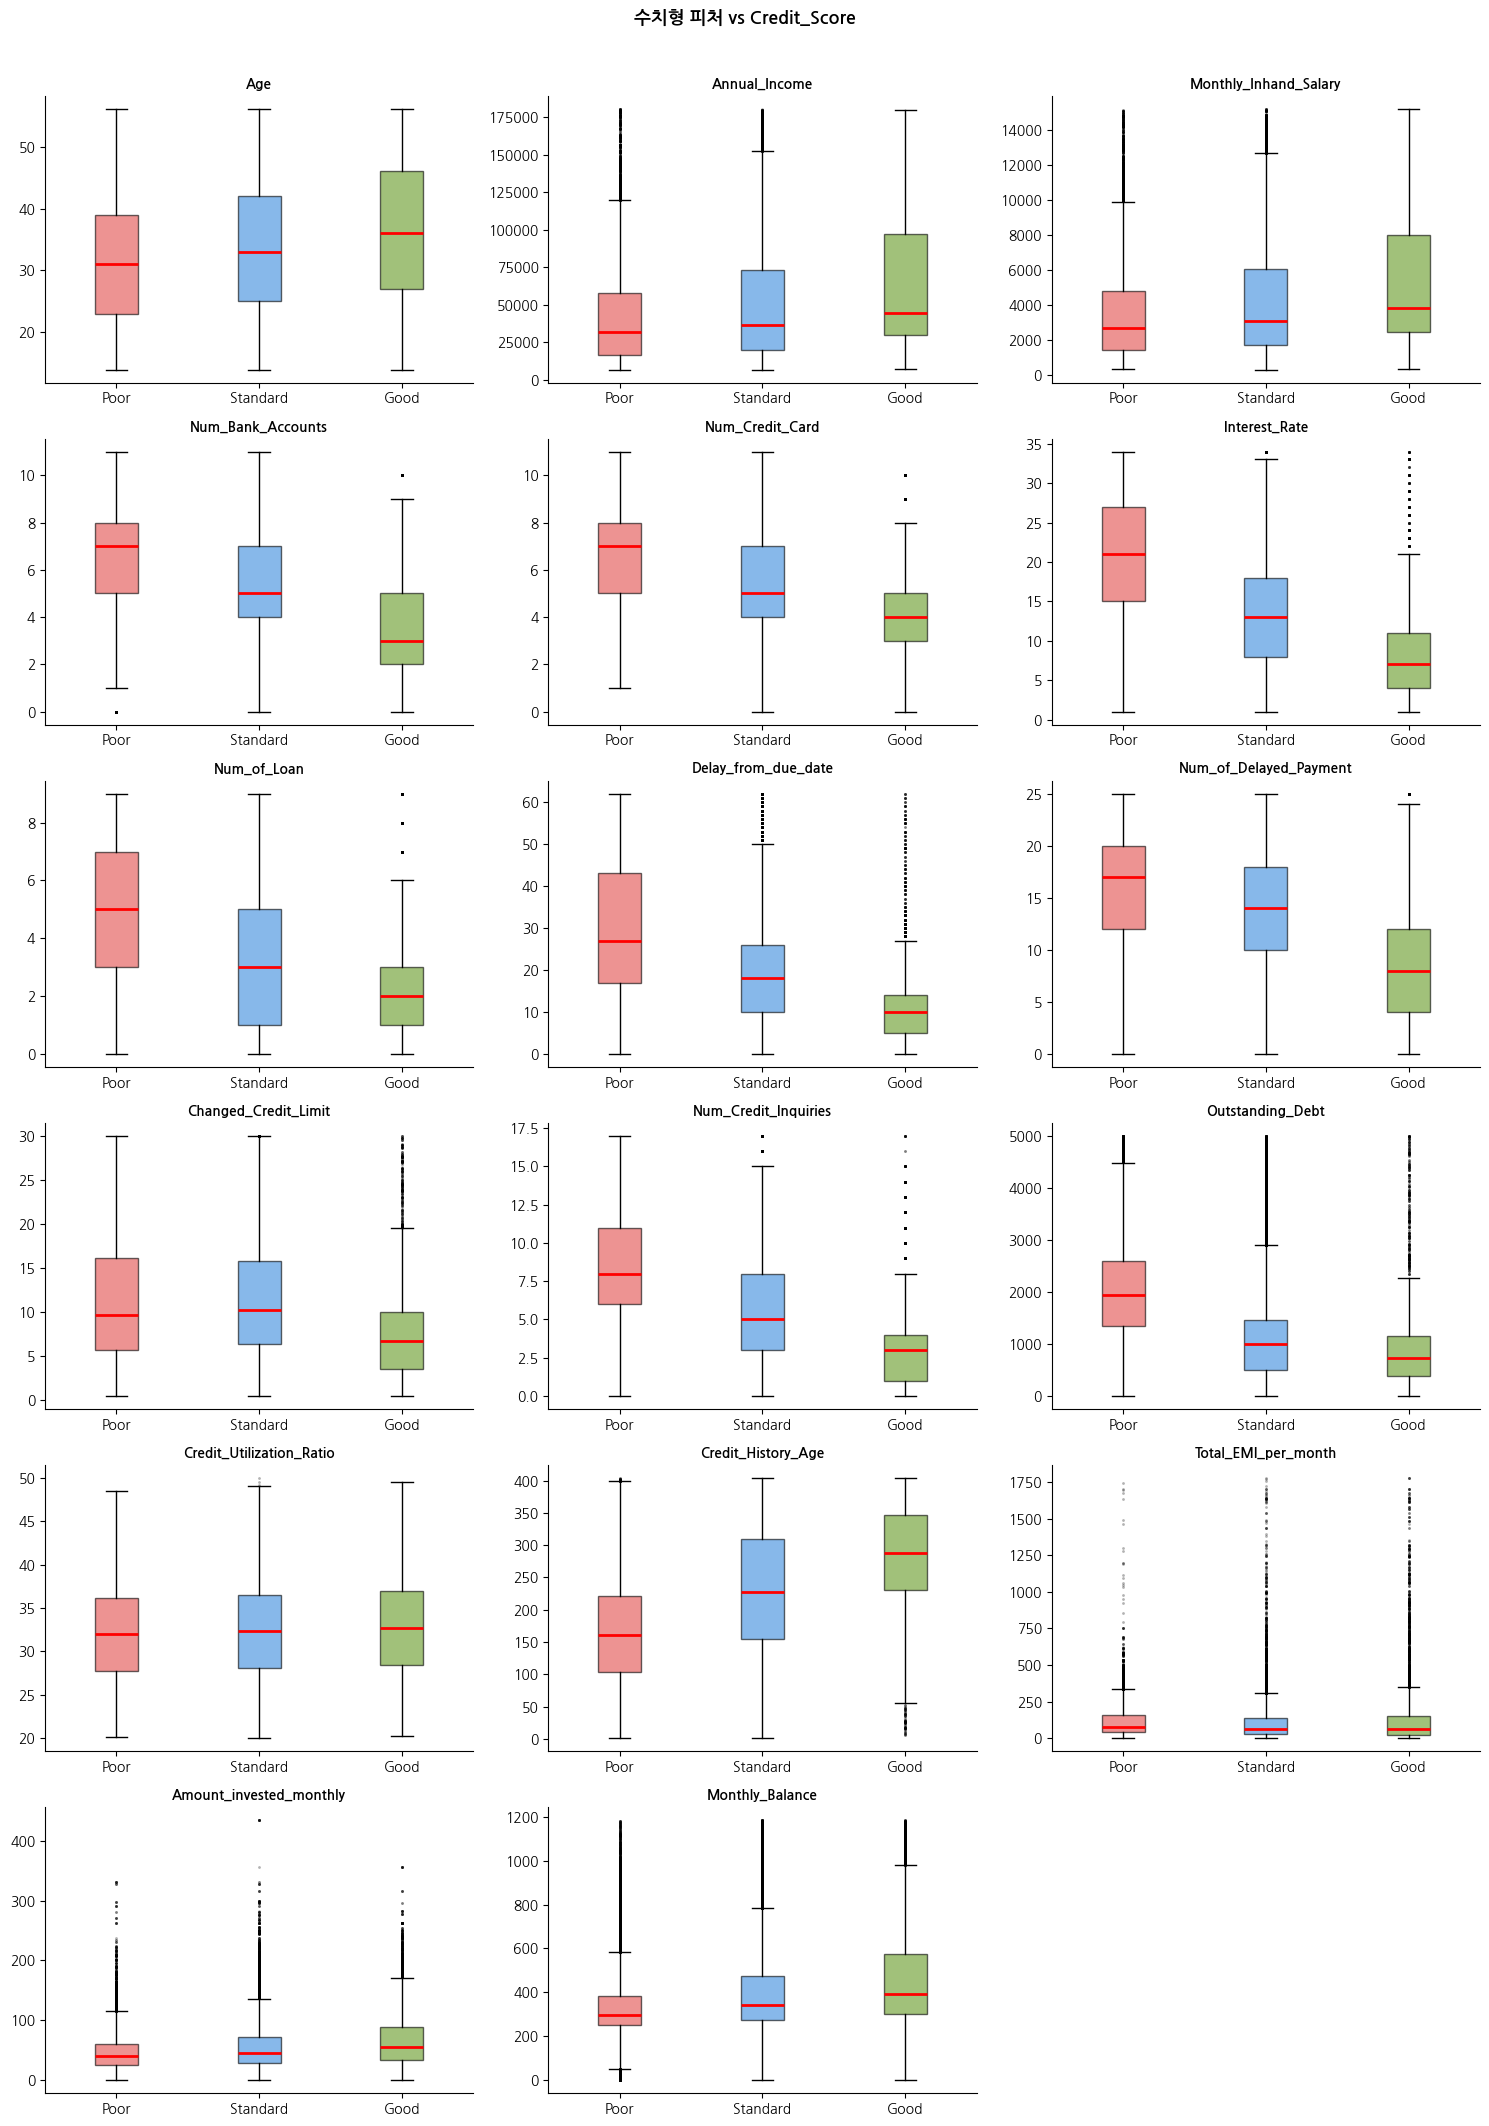

In [63]:
# 수치형 피처 vs Credit_Score 클래스별 박스플롯
num_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
            'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
            'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
            'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
            'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']

ncols = 3
nrows = -(-len(num_cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()
colors = ['#E24B4A', '#378ADD', '#639922']

for i, col in enumerate(num_cols):
    groups = [data[data['Credit_Score'] == s][col].dropna() for s in [0, 1, 2]]
    bp = axes[i].boxplot(groups, labels=['Poor', 'Standard', 'Good'],
                         patch_artist=True,
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].spines[['top', 'right']].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 피처 vs Credit_Score', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

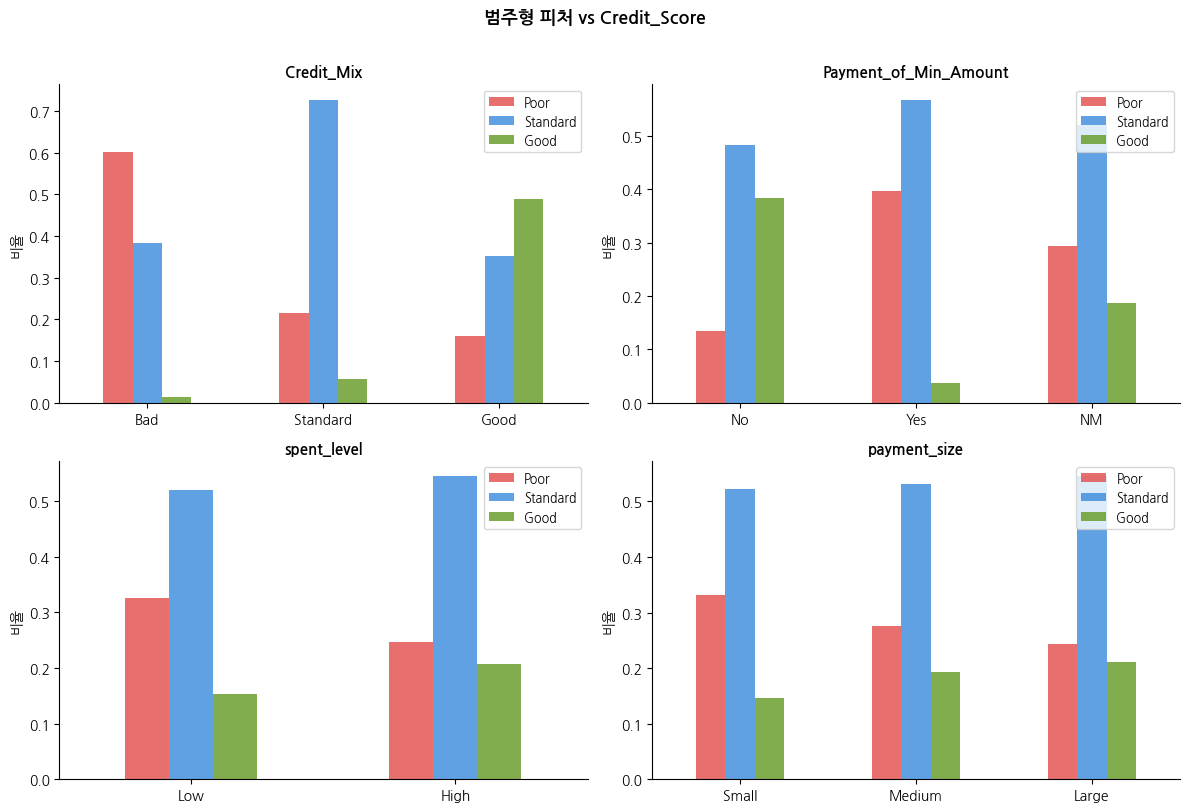

In [64]:
# 범주형 피처 vs Credit_Score 교차분석
cat_features = {
    'Credit_Mix':            {0:'Bad', 1:'Standard', 2:'Good'},
    'Payment_of_Min_Amount': {0:'No', 1:'Yes', 2:'NM'},
    'spent_level':           {0:'Low', 1:'High'},
    'payment_size':          {0:'Small', 1:'Medium', 2:'Large'}
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = ['#E24B4A', '#378ADD', '#639922']

for i, (col, label_map) in enumerate(cat_features.items()):
    ct = data.groupby([col, 'Credit_Score']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.index = [label_map[k] for k in ct_pct.index]
    ct_pct.columns = ['Poor', 'Standard', 'Good']
    ct_pct.plot(kind='bar', ax=axes[i], color=colors, alpha=0.8, edgecolor='none')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('비율')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].legend(['Poor', 'Standard', 'Good'], fontsize=9)

plt.suptitle('범주형 피처 vs Credit_Score', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

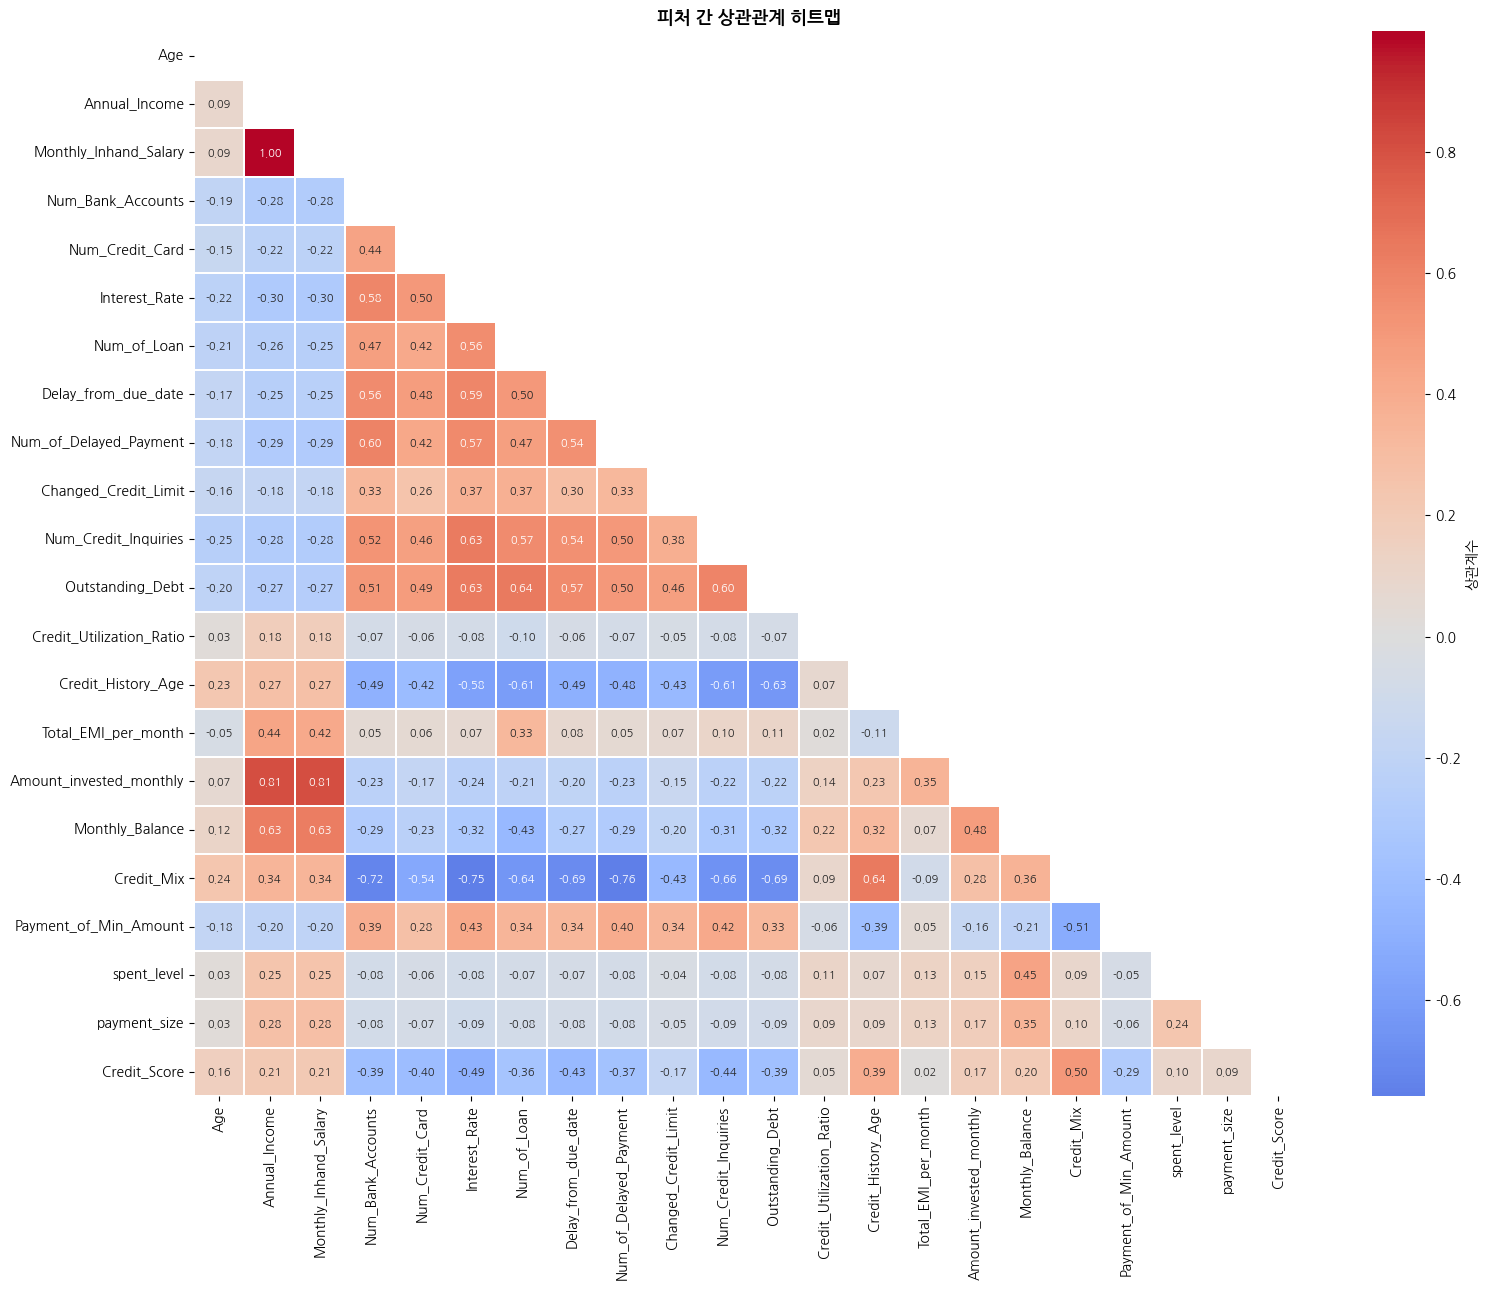

In [65]:
# 상관관계 히트맵
corr_cols = num_cols + ['Credit_Mix', 'Payment_of_Min_Amount', 'spent_level',
                        'payment_size', 'Credit_Score']
corr = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, annot_kws={'size': 8},
            ax=ax, cbar_kws={'label': '상관계수'})
ax.set_title('피처 간 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

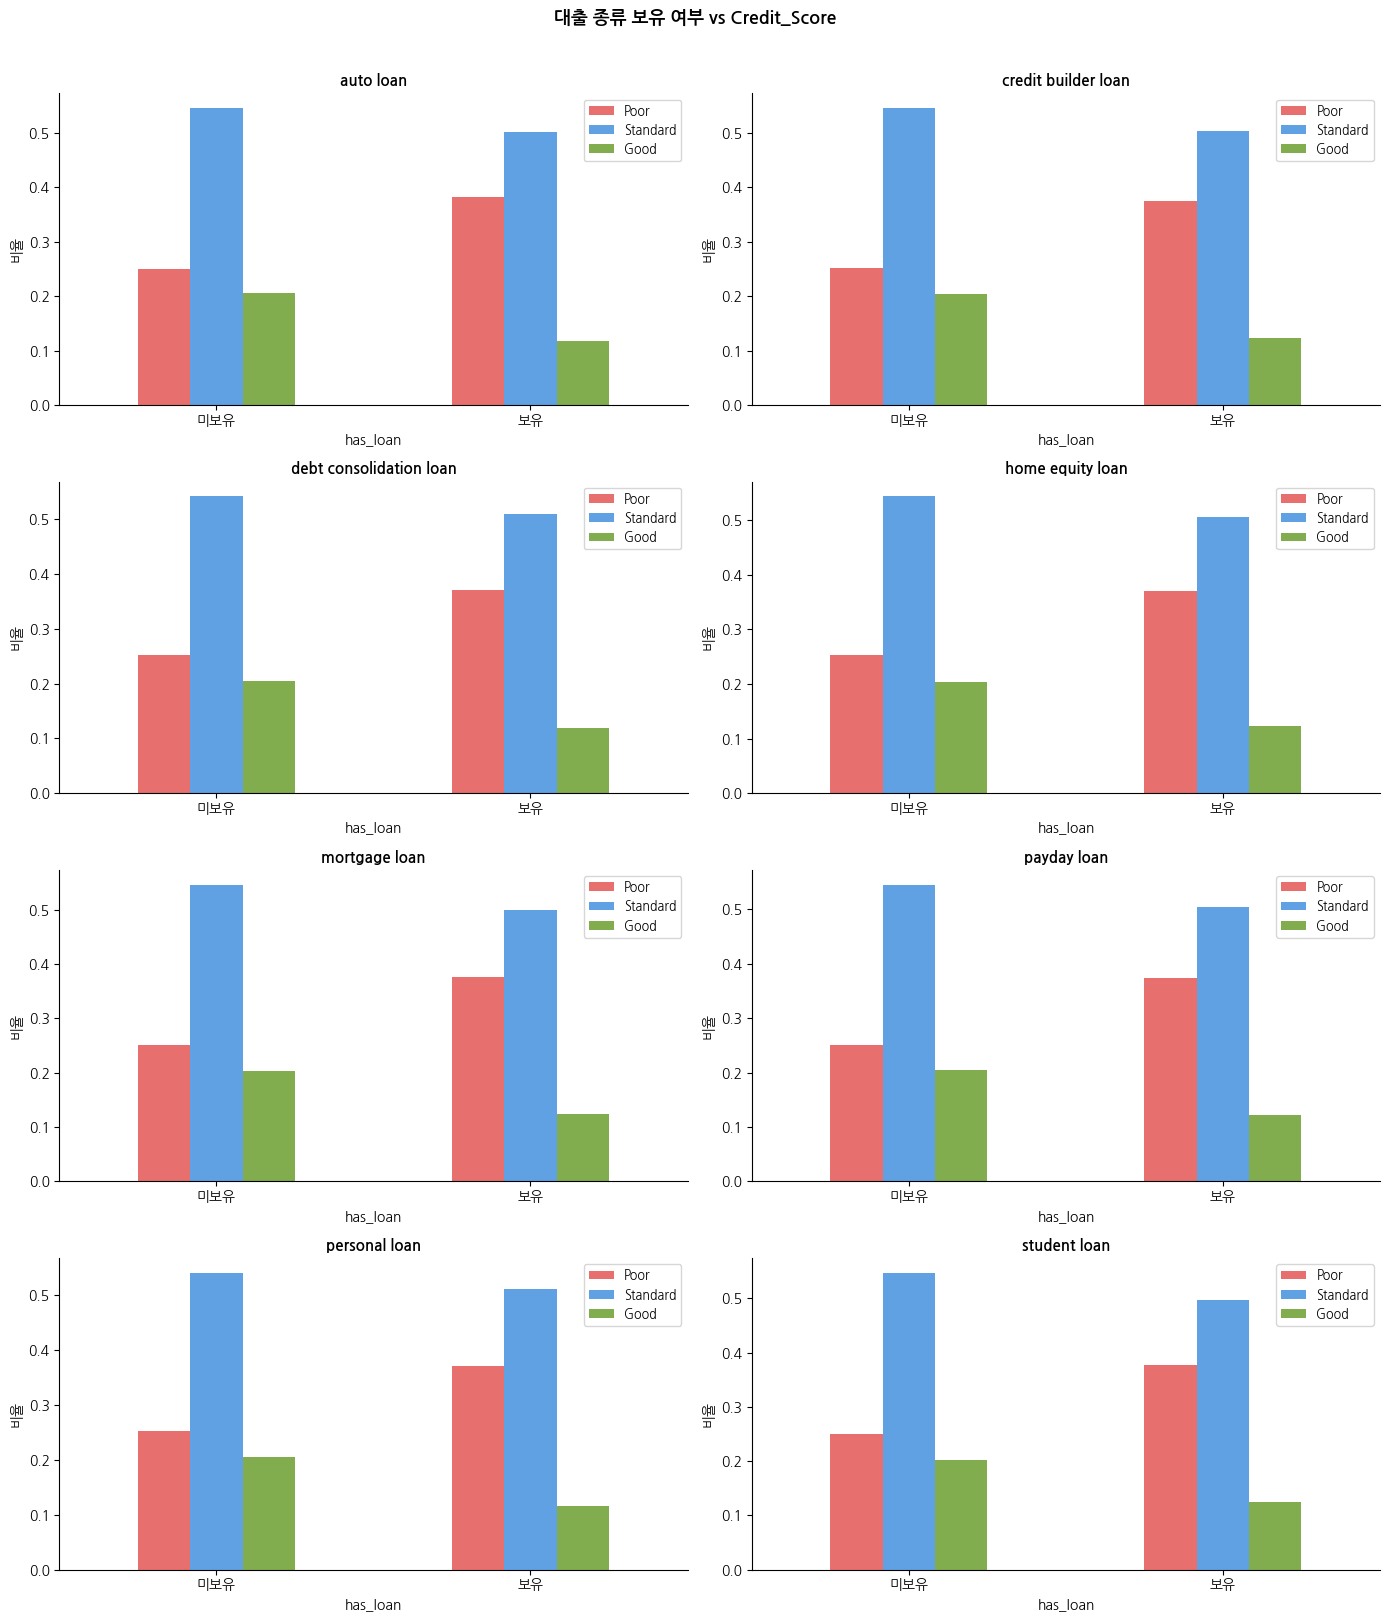

In [66]:
# 대출 종류 보유 여부 vs Credit_Score
loan_cols = [c for c in data.columns if c.startswith('loan_')]
results = []
for col in loan_cols:
    for has_loan in [0, 1]:
        subset = data[data[col] == has_loan]['Credit_Score']
        results.append({
            'loan': col.replace('loan_', '').replace('_', ' '),
            'has_loan': '보유' if has_loan else '미보유',
            'Poor':     (subset == 0).mean(),
            'Standard': (subset == 1).mean(),
            'Good':     (subset == 2).mean(),
        })

result_df = pd.DataFrame(results)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
colors = ['#E24B4A', '#378ADD', '#639922']

for i, loan_name in enumerate(result_df['loan'].unique()):
    sub = result_df[result_df['loan'] == loan_name].set_index('has_loan')
    sub[['Poor', 'Standard', 'Good']].plot(kind='bar', ax=axes[i],
                                            color=colors, alpha=0.8, edgecolor='none')
    axes[i].set_title(loan_name, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('비율')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].legend(['Poor', 'Standard', 'Good'], fontsize=9)

plt.suptitle('대출 종류 보유 여부 vs Credit_Score', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 6. Feature Selection 및 모델링

In [67]:
# Feature Selection 및 모델 선택 기준
# EDA 결과, 타겟과 상관이 거의 없는 Total_EMI_per_month(0.02), Credit_Utilization_Ratio(0.05)를 제거한다.
# 또한 EDA에서 강한 예측력을 보인 변수들의 조합으로 파생변수를 생성한다.
# debt_to_income: 부채/소득 비율로 재정 압박 지표
# delay_severity: 연체 횟수 × 연체 기간으로 연체 심각도 압축
# inquiry_per_card: 카드 수 대비 신용 조회수로 신용 과다 사용 신호
# balance_to_salary: 월수입 대비 잔액으로 저축 여력 지표
# loan_burden: 대출 수 × 이자율로 대출 부담도
# 파생변수 생성 후 원본 컬럼을 제거하여 다중공선성을 방지한다.
# 모델은 TabTransformer를 사용한다. 범주형 피처가 많은 이 데이터에서
# 트랜스포머 어텐션 메커니즘이 범주형 임베딩 간 관계를 효과적으로 학습할 수 있다.
# 수치형 피처는 StandardScaler로 정규화하고, 범주형은 임베딩으로 처리한다.
# 고객 단위 GroupShuffleSplit으로 동일 고객이 train/valid에 섞이지 않도록 분리한다.

data = pd.read_csv('train_preprocessed.csv')
data.drop(columns=['Total_EMI_per_month', 'Credit_Utilization_Ratio'], inplace=True)

# 파생변수 생성
data['debt_to_income']    = data['Outstanding_Debt'] / data['Annual_Income']
data['delay_severity']    = data['Delay_from_due_date'] * data['Num_of_Delayed_Payment']
data['inquiry_per_card']  = data['Num_Credit_Inquiries'] / (data['Num_Credit_Card'] + 1)
data['balance_to_salary'] = data['Monthly_Balance'] / (data['Monthly_Inhand_Salary'] + 1)
data['loan_burden']       = data['Num_of_Loan'] * data['Interest_Rate']

# 다중공선성 방지를 위한 원본 컬럼 제거
drop_cols = [
    'Outstanding_Debt', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
    'Num_Credit_Inquiries', 'Monthly_Balance', 'Num_of_Loan', 'Interest_Rate'
]
data.drop(columns=drop_cols, inplace=True)

# Month 0-index 변환 (임베딩 인덱스 오류 방지)
data['Month'] = data['Month'] - 1

print(f"파생변수 추가 및 컬럼 정리 후 shape: {data.shape}")
print(f"컬럼 목록:\n{data.columns.tolist()}")

파생변수 추가 및 컬럼 정리 후 shape: (100000, 29)
컬럼 목록:
['Customer_ID', 'Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Changed_Credit_Limit', 'Credit_Mix', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Credit_Score', 'loan_auto_loan', 'loan_credit_builder_loan', 'loan_debt_consolidation_loan', 'loan_home_equity_loan', 'loan_mortgage_loan', 'loan_payday_loan', 'loan_personal_loan', 'loan_student_loan', 'spent_level', 'payment_size', 'debt_to_income', 'delay_severity', 'inquiry_per_card', 'balance_to_salary', 'loan_burden']


In [68]:
# X, y, groups 분리
groups = data['Customer_ID'].values
data.drop(columns=['Customer_ID'], inplace=True)

cat_col_names = [
    'Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
    'spent_level', 'payment_size',
    'loan_auto_loan', 'loan_credit_builder_loan', 'loan_debt_consolidation_loan',
    'loan_home_equity_loan', 'loan_mortgage_loan', 'loan_payday_loan',
    'loan_personal_loan', 'loan_student_loan'
]
feature_names = data.drop(columns=['Credit_Score']).columns.tolist()
num_col_names = [c for c in feature_names if c not in cat_col_names]

X_cat = data[cat_col_names].values.astype(np.int64)
X_num = data[num_col_names].values.astype(np.float32)
y     = data['Credit_Score'].values.astype(np.int64)

# 고객 단위 train/valid 분리 (같은 고객이 양쪽에 섞이지 않도록)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(gss.split(X_cat, y, groups=groups))

X_cat_train, X_cat_valid = X_cat[train_idx], X_cat[valid_idx]
X_num_train, X_num_valid = X_num[train_idx], X_num[valid_idx]
y_train, y_valid         = y[train_idx], y[valid_idx]

# 수치형 정규화 (TabTransformer는 내부 BN 없어 필수)
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_valid = scaler.transform(X_num_valid)

print(f"범주형 피처 수: {len(cat_col_names)}, 수치형 피처 수: {len(num_col_names)}")
print(f"train: {X_cat_train.shape[0]}행, valid: {X_cat_valid.shape[0]}행")
print(f"학습 고객 수: {len(np.unique(groups[train_idx]))}, 검증 고객 수: {len(np.unique(groups[valid_idx]))}")

범주형 피처 수: 14, 수치형 피처 수: 13
train: 80000행, valid: 20000행
학습 고객 수: 10000, 검증 고객 수: 2500


In [ ]:
!pip install tab-transformer-pytorch

In [69]:
# TabTransformer 모델 ver1
from tab_transformer_pytorch import TabTransformer
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

# 클래스 가중치
class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"클래스 가중치: {dict(zip(['Poor','Standard','Good'], class_weights.round(3)))}")

cat_dims = [int(data[c].max()) + 1 for c in cat_col_names]

# TabTransformer 모델 정의
# 범주형: 트랜스포머 어텐션으로 임베딩 간 관계 학습
# 수치형: MLP로 처리 후 범주형 임베딩과 concat
# mlp_hidden_mults=(4,2): 항아리 형태 은닉층 (dim*4 → dim*2 → output)
# GeLU 활성화, dropout 0.1
model = TabTransformer(
    categories=tuple(cat_dims),
    num_continuous=len(num_col_names),
    dim=32,
    depth=3,
    heads=4,
    attn_dropout=0.1,
    ff_dropout=0.1,
    mlp_hidden_mults=(4, 2),
    mlp_act=nn.GELU(),
    num_special_tokens=2,
    dim_out=3,
).to(device)

def make_loader(X_cat, X_num, y, batch_size, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X_cat, dtype=torch.long),
        torch.tensor(X_num, dtype=torch.float32),
        torch.tensor(y,     dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_cat_train, X_num_train, y_train, batch_size=512)
valid_loader = make_loader(X_cat_valid, X_num_valid, y_valid, batch_size=512, shuffle=False)

optimizer = torch.optim.NAdam(model.parameters(), lr=1e-4, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

device: cuda
클래스 가중치: {'Poor': np.float64(1.15), 'Standard': np.float64(0.627), 'Good': np.float64(1.869)}


In [70]:
# 학습 루프 — patience=10 조기 종료, 최적 모델 자동 저장
best_acc   = 0
patience   = 10
no_improve = 0

for epoch in range(100):
    model.train()
    train_loss = 0
    for x_cat, x_num, labels in train_loader:
        x_cat, x_num, labels = x_cat.to(device), x_num.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(x_cat, x_num)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for x_cat, x_num, labels in valid_loader:
            x_cat, x_num = x_cat.to(device), x_num.to(device)
            outputs = model(x_cat, x_num)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    acc = accuracy_score(labels_all, preds_all)
    avg_loss = train_loss / len(train_loader)
    print(f"epoch {epoch:3d} | loss: {avg_loss:.5f} | valid_accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        no_improve = 0
        torch.save(model.state_dict(), '/content/tabtransformer_best.pt')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch} | best_accuracy: {best_acc:.4f}")
            break

    scheduler.step()

epoch   0 | loss: 0.81881 | valid_accuracy: 0.5861
epoch   1 | loss: 0.74486 | valid_accuracy: 0.6512
epoch   2 | loss: 0.72689 | valid_accuracy: 0.6367
epoch   3 | loss: 0.71585 | valid_accuracy: 0.6376
epoch   4 | loss: 0.71008 | valid_accuracy: 0.6387
epoch   5 | loss: 0.70141 | valid_accuracy: 0.6582
epoch   6 | loss: 0.69690 | valid_accuracy: 0.6407
epoch   7 | loss: 0.69470 | valid_accuracy: 0.6361
epoch   8 | loss: 0.69151 | valid_accuracy: 0.6408
epoch   9 | loss: 0.68761 | valid_accuracy: 0.6482
epoch  10 | loss: 0.68078 | valid_accuracy: 0.6435
epoch  11 | loss: 0.67891 | valid_accuracy: 0.6424
epoch  12 | loss: 0.67542 | valid_accuracy: 0.6442
epoch  13 | loss: 0.67321 | valid_accuracy: 0.6464
epoch  14 | loss: 0.66989 | valid_accuracy: 0.6443
epoch  15 | loss: 0.66630 | valid_accuracy: 0.6459

Early stopping at epoch 15 | best_accuracy: 0.6582


# 개선 사항

In [40]:
# 초반 데이터 처리 과정에 문제가 있다고 판단했다.
# 초기엔 한 고객이 학습과 검증 데이터에 섞이지 않도록 구성했으나, 성능이 65%대에 머물렀다.
# 검증셋이 학습에 없던 고객만으로 구성되어 모델이 새로운 패턴을 일반화하지 못한 것이 원인이었다.
# 이를 개선하기 위해 행 단위 무작위 분리(stratify)로 변경하였고,
# 동일 고객의 다른 월 데이터가 train/valid에 고르게 분포되어 클래스 패턴 학습을 개선한다.

In [71]:
# TabTransformer 모델 ver2
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tab_transformer_pytorch import TabTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

# ── 데이터 로드 ────────────────────────────────────────
data = pd.read_csv('train_preprocessed.csv')
data.drop(columns=['Customer_ID', 'Month',
                   'Total_EMI_per_month', 'Credit_Utilization_Ratio'], inplace=True)

# 파생변수 생성
data['debt_to_income']    = data['Outstanding_Debt'] / data['Annual_Income']
data['delay_severity']    = data['Delay_from_due_date'] * data['Num_of_Delayed_Payment']
data['inquiry_per_card']  = data['Num_Credit_Inquiries'] / (data['Num_Credit_Card'] + 1)
data['balance_to_salary'] = data['Monthly_Balance'] / (data['Monthly_Inhand_Salary'] + 1)
data['loan_burden']       = data['Num_of_Loan'] * data['Interest_Rate']

drop_cols = ['Outstanding_Debt', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
             'Num_Credit_Inquiries', 'Monthly_Balance', 'Num_of_Loan', 'Interest_Rate']
data.drop(columns=drop_cols, inplace=True)

# ── 범주형 / 수치형 분리 ───────────────────────────────
cat_col_names = [
    'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
    'spent_level', 'payment_size',
    'loan_auto_loan', 'loan_credit_builder_loan', 'loan_debt_consolidation_loan',
    'loan_home_equity_loan', 'loan_mortgage_loan', 'loan_payday_loan',
    'loan_personal_loan', 'loan_student_loan'
]
num_col_names = [c for c in data.columns
                 if c not in cat_col_names + ['Credit_Score']]

print(f"범주형: {len(cat_col_names)}개, 수치형: {len(num_col_names)}개")
print(f"수치형 컬럼: {num_col_names}")

# ── X, y 분리 ──────────────────────────────────────────
X_cat = data[cat_col_names].values.astype(np.int64)
X_num = data[num_col_names].values.astype(np.float32)
y     = data['Credit_Score'].values.astype(np.int64)

# ── 무작위 분리 (행 단위, stratify) ───────────────────
X_cat_train, X_cat_valid, X_num_train, X_num_valid, y_train, y_valid = train_test_split(
    X_cat, X_num, y, test_size=0.2, random_state=42, stratify=y
)

# ── 수치형 스케일링 ────────────────────────────────────
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_valid = scaler.transform(X_num_valid)

print(f"train: {X_cat_train.shape[0]}행, valid: {X_cat_valid.shape[0]}행")
print(f"타겟 분포: {pd.Series(y_train).value_counts().to_dict()}")

# ── 클래스 가중치 (제거 — 무작위 샘플이므로 불균형 자연 반영) ──
# class_weight 제거하고 일반 CEL 사용
criterion = nn.CrossEntropyLoss()

# ── DataLoader ─────────────────────────────────────────
def make_loader(X_cat, X_num, y, batch_size, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X_cat, dtype=torch.long),
        torch.tensor(X_num, dtype=torch.float32),
        torch.tensor(y,     dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_cat_train, X_num_train, y_train, batch_size=512)
valid_loader = make_loader(X_cat_valid, X_num_valid, y_valid, batch_size=512, shuffle=False)

# ── TabTransformer 모델 ────────────────────────────────
cat_dims = [int(data[c].max()) + 1 for c in cat_col_names]

model = TabTransformer(
    categories=tuple(cat_dims),
    num_continuous=len(num_col_names),
    dim=32,
    depth=3,
    heads=4,
    attn_dropout=0.1,
    ff_dropout=0.1,
    mlp_hidden_mults=(4, 2),
    mlp_act=nn.GELU(),
    num_special_tokens=2,
    dim_out=3,
).to(device)

optimizer = torch.optim.NAdam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ── 학습 루프 ──────────────────────────────────────────
best_acc   = 0
patience   = 10
no_improve = 0

for epoch in range(100):
    model.train()
    train_loss = 0
    for x_cat, x_num, labels in train_loader:
        x_cat, x_num, labels = x_cat.to(device), x_num.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(x_cat, x_num)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for x_cat, x_num, labels in valid_loader:
            x_cat, x_num = x_cat.to(device), x_num.to(device)
            outputs = model(x_cat, x_num)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    acc = accuracy_score(labels_all, preds_all)
    avg_loss = train_loss / len(train_loader)
    print(f"epoch {epoch:3d} | loss: {avg_loss:.5f} | valid_accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        no_improve = 0
        torch.save(model.state_dict(), '/content/tabtransformer_best.pt')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch} | best_accuracy: {best_acc:.4f}")
            break

    scheduler.step()

# ── 최종 평가 ──────────────────────────────────────────
model.load_state_dict(torch.load('/content/tabtransformer_best.pt'))
model.eval()
preds_all, labels_all = [], []
with torch.no_grad():
    for x_cat, x_num, labels in valid_loader:
        x_cat, x_num = x_cat.to(device), x_num.to(device)
        outputs = model(x_cat, x_num)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(labels.numpy())

print(f"\nValidation Accuracy: {best_acc:.4f}")
print(classification_report(labels_all, preds_all, target_names=['Poor', 'Standard', 'Good']))

device: cuda
범주형: 13개, 수치형: 13개
수치형 컬럼: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Changed_Credit_Limit', 'Credit_History_Age', 'Amount_invested_monthly', 'debt_to_income', 'delay_severity', 'inquiry_per_card', 'balance_to_salary', 'loan_burden']
train: 80000행, valid: 20000행
타겟 분포: {1: 42539, 0: 23199, 2: 14262}
epoch   0 | loss: 0.85206 | valid_accuracy: 0.6564
epoch   1 | loss: 0.73317 | valid_accuracy: 0.6609
epoch   2 | loss: 0.72039 | valid_accuracy: 0.6703
epoch   3 | loss: 0.70968 | valid_accuracy: 0.6726
epoch   4 | loss: 0.69536 | valid_accuracy: 0.6801
epoch   5 | loss: 0.66252 | valid_accuracy: 0.7000
epoch   6 | loss: 0.63376 | valid_accuracy: 0.7156
epoch   7 | loss: 0.60070 | valid_accuracy: 0.7272
epoch   8 | loss: 0.56546 | valid_accuracy: 0.7357
epoch   9 | loss: 0.53088 | valid_accuracy: 0.7582
epoch  10 | loss: 0.46855 | valid_accuracy: 0.7653
epoch  11 | loss: 0.44490 | valid_accuracy: 0.7765
epoch  12 | loss: 0.42454 

In [ ]:
# ver1: GroupShuffleSplit으로 고객 단위 분리 → 검증셋이 학습에 없던 고객만으로 구성되어 모델이 새로운 고객 패턴을 일반화하지 못하고 성능이 65%대에 머물렀다.
# ver2: 행 단위 무작위 분리(stratify)로 변경 → 동일 고객의 다른 월 데이터가 train/valid에 고르게 분포되어 클래스 패턴 학습이 개선되었다.
# 또한 클래스 가중치 제거 후 일반 CEL 적용으로 Standard 클래스 recall이 개선되었다.

# Validation Score

In [72]:
# Validation Score 출력
# TabTransformer 모델의 최적 epoch 기준 검증 정확도와 클래스별 성능을 출력한다.
# 클래스 불균형(Poor 29%, Standard 53%, Good 18%)을 고려하여
# accuracy 외 precision, recall, f1-score를 함께 확인한다.

model.load_state_dict(torch.load('/content/tabtransformer_best.pt'))
model.eval()
preds_all, labels_all = [], []
with torch.no_grad():
    for x_cat, x_num, labels in valid_loader:
        x_cat, x_num = x_cat.to(device), x_num.to(device)
        outputs = model(x_cat, x_num)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(labels.numpy())

print(f"Validation Accuracy: {best_acc:.4f}")
print(classification_report(labels_all, preds_all, target_names=['Poor', 'Standard', 'Good']))

Validation Accuracy: 0.7870
              precision    recall  f1-score   support

        Poor       0.77      0.81      0.79      5799
    Standard       0.82      0.78      0.80     10635
        Good       0.72      0.76      0.74      3566

    accuracy                           0.79     20000
   macro avg       0.77      0.79      0.78     20000
weighted avg       0.79      0.79      0.79     20000



In [ ]:
# 빅데이터 시대에 특정 개인의 누적 이력 없이도, 동일 시점의 집계 데이터만으로 신용등급을 예측할 수 있음을 확인하였다.
# 이는 DL 모델 설계 시 데이터 구조에 맞는 입력 방식 선택이 성능에 직결됨을 시사한다.
# 단, 본 모델의 한계는 명확하다. 학습 데이터가 특정 연도 1~8월에 한정되므로, 해당 기간의 분포 특성을 벗어난 시점에 대한 일반화 성능은 보장하기 어렵다.
# 큰 경제적 충격이 없는 안정적인 환경을 전제로, 동일한 월별 집계 구조를 가진 데이터에 한해 동일 연도 9~12월 신용등급 예측에도 유의미한 결과를 기대할 수 있다.